# Mestrado em Inteligência Artificial 25/26
# Model-Based RL: MCTS on TicTacToe

In [ ]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt

from mia_rl.envs.tictactoe import TicTacToeEnv
from mia_rl.agents.planning.mcts import MCTSAgent
from mia_rl.experiments.mcts_tictactoe import (
    make_mcts_policy,
    evaluate_vs_random,
    evaluate_mcts_vs_reinforce,
)
from mia_rl.experiments.tictactoe import play_game, play_game_vs_human
from mia_rl.policies.tictactoe import random_action

---
## 1. From model-free to model-based

| | Model-free (REINFORCE) | Model-based (MCTS) |
|---|---|---|
| Requires training? | ✅ yes                | ❌ no — search at decision time |
| Uses environment model? | ❌ only real experience | ✅ simulates futures internally |
| Stores knowledge in | weight matrix θ | search tree (discarded after each move) |
| Compute cost | upfront (training) | per move (planning) |

MCTS treats the **environment itself as the model** — it runs many simulated games from the current state and picks the action with the best outcomes.

---
## 2. The four phases of MCTS

Each **simulation** (tree iteration) consists of four steps:

1. **Selection** — starting at the root, follow the **tree policy** (UCB1) to traverse the tree to a leaf node that still has unexplored actions (or is terminal):
$$\text{UCB1}(s,a) = -Q(s,a) + c\,\sqrt{\frac{\ln N(s)}{N(s,a)}}$$
   The minus sign on $Q$ exists because the parent and child are **opponents** — what is good for the child is bad for the parent.

1. **Expansion** — add one new child node for an untried action (using the default policy).

2. **Simulation** — from the newly added node, simulate a complete episode: actions inside the tree follow the **tree policy**; actions outside the tree follow the **default rollout policy** (random).

4. **Backup** — the return from the episode is used to update the action values $Q(s,a)$ of all traversed edges (from the tree policy only), alternating sign at each level since players alternate.

After all simulations, pick the **most-visited** child of the root (robust to outlier rollouts).

> **Simplification vs. slides**: the slides note the tree can be reused across moves. Here we rebuild a fresh tree on every call for simplicity.

---
## 3. Instant play — no training needed

Unlike REINFORCE, MCTS is ready to play immediately.

In [2]:
env   = TicTacToeEnv()
agent = MCTSAgent(n_simulations=1_000)

mcts_policy = make_mcts_policy(agent)

print("=" * 40)
print(" MCTS (X)  vs  Random (O)")
print("=" * 40)
play_game(env, mcts_policy, random_action, render=True)

 MCTS (X)  vs  Random (O)
Initial board:
 1 | 2 | 3 
---+---+---
 4 | 5 | 6 
---+---+---
 7 | 8 | 9 

Player X plays cell 7:
 1 | 2 | 3 
---+---+---
 4 | 5 | 6 
---+---+---
 X | 8 | 9 

Player O plays cell 9:
 1 | 2 | 3 
---+---+---
 4 | 5 | 6 
---+---+---
 X | 8 | O 

Player X plays cell 3:
 1 | 2 | X 
---+---+---
 4 | 5 | 6 
---+---+---
 X | 8 | O 

Player O plays cell 4:
 1 | 2 | X 
---+---+---
 O | 5 | 6 
---+---+---
 X | 8 | O 

Player X plays cell 5:
 1 | 2 | X 
---+---+---
 O | X | 6 
---+---+---
 X | 8 | O 

X wins!


1

---
## 4. Visualising the search tree

After running MCTS from a mid-game state we can inspect the search tree and see **where the agent concentrated its simulations**.

Each child of the root represents one possible move. Key statistics per child:
- **N** — visit count: how many simulations passed through this node
- **Q** — win-rate estimate from the root player's perspective: $Q = -v/N$ (negated because `value_sum` is stored from the child's point of view)
- The **chosen action** (most-visited child) is highlighted in green

Board state:
 X | O | 3 
---+---+---
 O | X | 6 
---+---+---
 7 | 8 | 9 

Running MCTS (1000 simulations)…
Chosen action: cell 9  (win!)


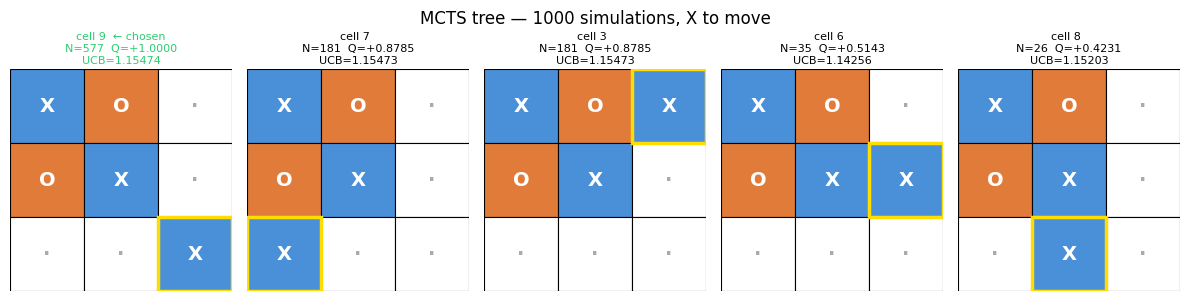

In [3]:
def plot_mcts_tree(root, title="MCTS search tree — root children"):
    """Visualise the first level of the MCTS tree (root + its children).

    Each subplot shows one possible move with the board state, visit count N,
    Q-value (win rate from the root player's perspective), and UCB1 score.
    The chosen action (most-visited child) is highlighted with a green border.
    """
    import math

    children = sorted(root.children.values(), key=lambda n: n.visit_count, reverse=True)
    n_children = len(children)
    best_action = max(root.children.values(), key=lambda n: n.visit_count).action
    c = math.sqrt(2)  # UCB exploration constant

    cols = min(n_children, 5)
    rows = math.ceil(n_children / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.4, rows * 3.0))
    axes = np.array(axes).flatten()

    SYMBOLS = {0: "·", 1: "X", -1: "O"}
    COLORS  = {0: "white", 1: "#4a90d9", -1: "#e07b39"}

    for ax, child in zip(axes, children):
        board = child.state

        # Draw 3×3 grid
        for r in range(3):
            for col_idx in range(3):
                idx = r * 3 + col_idx
                val = board[idx]
                rect = plt.Rectangle(
                    [col_idx, 2 - r], 1, 1,
                    facecolor=COLORS[val], edgecolor="black", linewidth=0.8
                )
                ax.add_patch(rect)
                ax.text(
                    col_idx + 0.5, 2 - r + 0.5, SYMBOLS[val],
                    ha="center", va="center", fontsize=14, fontweight="bold",
                    color="white" if val != 0 else "#aaaaaa"
                )

        # Highlight the played cell
        pr, pc = divmod(child.action, 3)
        ax.add_patch(plt.Rectangle(
            [pc, 2 - pr], 1, 1,
            facecolor="none", edgecolor="#ffdd00", linewidth=2.5
        ))

        ax.set_xlim(0, 3)
        ax.set_ylim(0, 3)
        ax.set_aspect("equal")
        ax.axis("off")

        # Stats
        N = child.visit_count
        Q = (-child.value_sum / N) if N > 0 else 0.0   # from root's perspective
        ucb = child.ucb(c) if N > 0 else float("inf")
        ucb_str = f"{ucb:.5f}" if ucb != float("inf") else "∞"

        chosen = child.action == best_action
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor("#2ecc71" if chosen else "#cccccc")
            spine.set_linewidth(3.5 if chosen else 1.0)

        label = f"cell {child.action + 1}  {'← chosen' if chosen else ''}\nN={N}  Q={Q:+.4f}\nUCB={ucb_str}"
        ax.set_title(label, fontsize=8, color="#2ecc71" if chosen else "black", pad=4)

    for ax in axes[n_children:]:
        ax.axis("off")

    fig.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()


# ── Run MCTS on a mid-game state and visualise the tree ───────────────────────
#   X | O | ·
#   O | X | ·      X has the main diagonal (0→4), one move from winning
#   · | · | ·      X to move — can X win immediately?

mid_game_state = (1, -1, 0, -1, 1, 0, 0, 0, 0)   # X=cells 0,4 — O=cells 1,3
player_to_move = 1                                  # X's turn

env_viz = TicTacToeEnv()
env_viz.board = mid_game_state
env_viz.current_player = player_to_move

print("Board state:")
env_viz.render(mid_game_state)
print(f"\nRunning MCTS ({agent.n_simulations} simulations)…")

action, root = agent.search(mid_game_state, player_to_move)
print(f"Chosen action: cell {action + 1}  ({'win!' if action == 8 else '?'})")

plot_mcts_tree(root, title=f"MCTS tree — {agent.n_simulations} simulations, X to move")

---
## 5. Effect of number of simulations

More simulations = deeper, wider search = stronger play, but slower per move.

TicTacToe has at most 9! = 362 880 possible games, so even a small number of simulations covers a meaningful fraction.

In [4]:
import time

sim_counts  = [10, 50, 100, 200, 500, 1000]
win_x, win_o, times = [], [], []
N_EVAL = 300

for n in sim_counts:
    a = MCTSAgent(n_simulations=n)
    t0 = time.time()
    wx, _, _ = evaluate_vs_random(env, a, n_games=N_EVAL, as_player=1)
    wo, _, _ = evaluate_vs_random(env, a, n_games=N_EVAL, as_player=-1)
    elapsed = time.time() - t0
    win_x.append(wx); win_o.append(wo); times.append(elapsed)
    print(f"n={n:4d}  win_X={wx:.0%}  win_O={wo:.0%}  ({elapsed:.1f}s)")

n=  10  win_X=91%  win_O=71%  (0.5s)
n=  50  win_X=99%  win_O=84%  (2.4s)
n= 100  win_X=98%  win_O=87%  (4.4s)
n= 200  win_X=99%  win_O=88%  (9.3s)
n= 500  win_X=99%  win_O=91%  (24.4s)
n=1000  win_X=98%  win_O=93%  (51.7s)


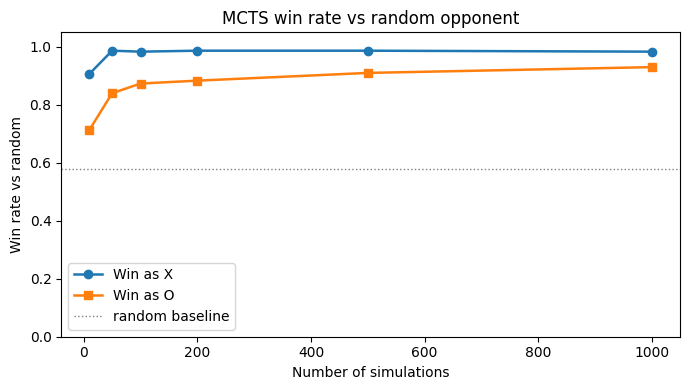

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sim_counts, win_x, marker='o', label='Win as X', color='tab:blue',   linewidth=1.8)
ax.plot(sim_counts, win_o, marker='s', label='Win as O', color='tab:orange',  linewidth=1.8)
ax.axhline(0.58, color='grey', linestyle=':', linewidth=1, label='random baseline')
ax.set_xlabel('Number of simulations'); ax.set_ylabel('Win rate vs random')
ax.set_title('MCTS win rate vs random opponent')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

---
## 6. MCTS vs trained REINFORCE

We train REINFORCE with the same hyperparameters used in the Policy Gradient notebook and then pit it against MCTS.

In [7]:
from mia_rl.agents.control.reinforce import ReinforceAgent
from mia_rl.experiments.reinforce_tictactoe import train, make_reinforce_policy

# Same hyperparameters as TicTacToe_PolicyGradient.ipynb
SEED            = 42
NUM_EPISODES    = 100_000
ALPHA           = 0.02
GAMMA           = 1.0
ENTROPY_BETA    = 0.01
RANDOM_OPP_FRAC = 0.5

reinforce_agent = ReinforceAgent(alpha=ALPHA, gamma=GAMMA, entropy_beta=ENTROPY_BETA, seed=SEED)
results = train(
    reinforce_agent,
    num_episodes=NUM_EPISODES,
    random_opp_fraction=RANDOM_OPP_FRAC,
    eval_every=10_000,
    eval_episodes=200,
)

print(f"REINFORCE — win as X: {results['win_rates_as_x'][-1]:.1%}  |  win as O: {results['win_rates_as_o'][-1]:.1%}")

REINFORCE — win as X: 98.5%  |  win as O: 81.0%


In [8]:
reinforce_policy = make_reinforce_policy(reinforce_agent, greedy=True)
mcts_strong      = MCTSAgent(n_simulations=1000)
N = 300

# MCTS as X (first mover) vs REINFORCE as O
w_x, d_x, l_x = evaluate_mcts_vs_reinforce(env, mcts_strong, reinforce_policy, n_games=N, mcts_as_player=1)
# MCTS as O (second mover) vs REINFORCE as X
w_o, d_o, l_o = evaluate_mcts_vs_reinforce(env, mcts_strong, reinforce_policy, n_games=N, mcts_as_player=-1)

print("MCTS (1000 sims) vs trained REINFORCE")
print(f"  MCTS plays X:  win={w_x:.0%}  draw={d_x:.0%}  loss={l_x:.0%}")
print(f"  MCTS plays O:  win={w_o:.0%}  draw={d_o:.0%}  loss={l_o:.0%}")

MCTS (1000 sims) vs trained REINFORCE
  MCTS plays X:  win=100%  draw=0%  loss=0%
  MCTS plays O:  win=99%  draw=0%  loss=1%


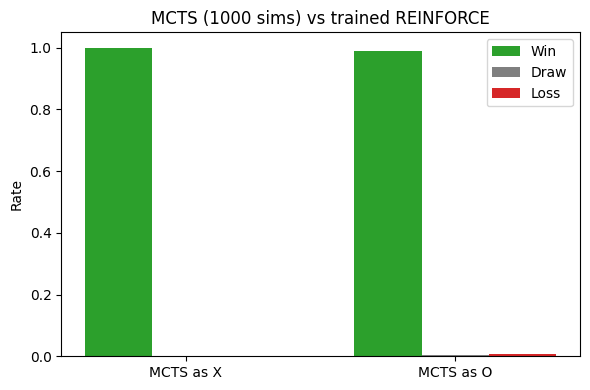

In [9]:
labels   = ['MCTS as X', 'MCTS as O']
wins     = [w_x,  w_o]
draws    = [d_x,  d_o]
losses   = [l_x,  l_o]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width, wins,   width, label='Win',  color='tab:green')
ax.bar(x,         draws,  width, label='Draw', color='tab:grey')
ax.bar(x + width, losses, width, label='Loss', color='tab:red')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Rate')
ax.set_ylim(0, 1.05)
ax.set_title('MCTS (1000 sims) vs trained REINFORCE')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Watch a game: MCTS vs REINFORCE

In [10]:
print("=" * 40)
print(" MCTS (X)  vs  REINFORCE (O)")
print("=" * 40)
play_game(env, mcts_policy, reinforce_policy, render=True)

 MCTS (X)  vs  REINFORCE (O)
Initial board:
 1 | 2 | 3 
---+---+---
 4 | 5 | 6 
---+---+---
 7 | 8 | 9 

Player X plays cell 5:
 1 | 2 | 3 
---+---+---
 4 | X | 6 
---+---+---
 7 | 8 | 9 

Player O plays cell 9:
 1 | 2 | 3 
---+---+---
 4 | X | 6 
---+---+---
 7 | 8 | O 

Player X plays cell 6:
 1 | 2 | 3 
---+---+---
 4 | X | X 
---+---+---
 7 | 8 | O 

Player O plays cell 7:
 1 | 2 | 3 
---+---+---
 4 | X | X 
---+---+---
 O | 8 | O 

Player X plays cell 4:
 1 | 2 | 3 
---+---+---
 X | X | X 
---+---+---
 O | 8 | O 

X wins!


1

---
## 8. Play against MCTS

```
 1 | 2 | 3
-----------
 4 | 5 | 6
-----------
 7 | 8 | 9
```

`human_plays=-1` → you play as O (second). Change to `1` to play as X.

In [15]:
play_game_vs_human(env, mcts_policy, human_plays=-1)

Initial board:
 1 | 2 | 3 
---+---+---
 4 | 5 | 6 
---+---+---
 7 | 8 | 9 

Player X plays cell 5:
 1 | 2 | 3 
---+---+---
 4 | X | 6 
---+---+---
 7 | 8 | 9 



Player O plays cell 3:
 1 | 2 | O 
---+---+---
 4 | X | 6 
---+---+---
 7 | 8 | 9 

Player X plays cell 2:
 1 | X | O 
---+---+---
 4 | X | 6 
---+---+---
 7 | 8 | 9 

Player O plays cell 4:
 1 | X | O 
---+---+---
 O | X | 6 
---+---+---
 7 | 8 | 9 

Player X plays cell 8:
 1 | X | O 
---+---+---
 O | X | 6 
---+---+---
 7 | X | 9 

X wins!


1